# Explaining a Radiology Image Classifier in Natural Language

**Pipeline:** `image -> frozen CNN classifier -> Grad-CAM -> heatmap -> prompted image-to-text decoder -> human-readable explanation`

**Dataset:** ROCOv2 (Radiology Objects in COntext, version 2) via the Hugging Face mirror `eltorio/ROCOv2-radiology`.

---

## What this notebook does, and why it is built this way

The research question is *not* "can we classify radiology images well". It is: **can the output of a
saliency method be turned into text that a human can read, and is that text actually tied to the
visual evidence rather than being a generic caption?**

### 1. Classifier: ResNet-50, backbone frozen, linear probe on top
ImageNet class labels ("nematode", "jigsaw puzzle") are meaningless on radiographs, so a Grad-CAM over a
raw ImageNet head would explain nothing. Instead:

* the **entire convolutional backbone stays frozen** (no weight ever updated), so the features being
  explained are the pretrained ones;
* only a **single linear layer** (2048 -> K) is trained on the ROCOv2 UMLS concepts, multi-label, with BCE.

This trains in seconds on cached features and gives a label space that is interpretable.
It also has a useful theoretical property: for a `global-average-pool + linear` head, **Grad-CAM reduces
exactly to CAM**, so the heatmap is provably the head's own weighting of the feature maps, not an
approximation of it.

ResNet rather than a ViT because Grad-CAM on convolutional `layer4` needs no token-reshaping tricks and
behaves reliably.

### 2. Grad-CAM
Implemented directly with forward hooks + tensor hooks (no external XAI package). It is computed
**per predicted concept**, so we can ask separately "where did the model look when it decided *CT*?"
and "...when it decided *chest*?".

### 3. Decoder grounding (the part that makes the text an *explanation* rather than a caption)
A captioner handed the whole image produces something unrelated to the heatmap. Three mechanisms
prevent that:

1. **Prompt conditioning** - BLIP's conditional mode is seeded with the classifier's own prediction
   (`"a ct scan of the chest showing"`), anchoring the caption to the classified concept.
2. **Focus-region captioning** - the heatmap's bounding box is cropped from the *original resolution*
   image and captioned on its own. This caption physically cannot describe anything outside the
   salient region.
3. **Faithfulness measurement folded into the text** - a deletion test (blank the top-20% most salient
   pixels, recompute confidence) plus a random-mask control of identical area. The explanation states
   *how much* the highlighted evidence mattered instead of asserting that it mattered.

The final fusion is a **deterministic template**, not a free-running LLM. A generative model asked to
narrate a heatmap will confabulate about it, which is precisely the failure mode this experiment
exists to avoid.

### 4. Evaluation
* classifier: sample-averaged F1, micro-F1, mAP
* explanation faithfulness: confidence drop under salient deletion vs. random deletion of equal area
* text: BLEU-1..4, ROUGE-L, METEOR and modality-term recall against the gold ROCOv2 captions, reported
  as an **ablation** over four systems (plain caption -> concept-conditioned -> heatmap-grounded ->
  full explanation) so the contribution of the grounding is visible.

---

**Requirements:** Kaggle GPU (T4 is enough) with **Internet enabled** (needed for the torchvision and
Hugging Face weight downloads). Everything else - paths, device, batching, downloads - is handled
automatically.

In [1]:
# Kaggle already ships these; this pins sane minimum versions and is a no-op if satisfied.
!pip install -q "transformers>=4.38" "datasets>=2.18" "accelerate>=0.27"

In [2]:
import os
import re
import json
import math
import time
import random
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from datasets import load_dataset

warnings.filterwarnings("ignore")
Image.MAX_IMAGE_PIXELS = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if torch.cuda.is_available():
    print("gpu   :", torch.cuda.get_device_name(0))
print("torch :", torch.__version__)

device: cuda
gpu   : Tesla T4
torch : 2.10.0+cu128


## 1. Configuration

Everything tunable lives here. The defaults are sized so the whole notebook runs end to end in roughly
20-30 minutes on a Kaggle T4, dominated by streaming the dataset.

`STREAMING = True` is important: the full ROCOv2 parquet export is ~19 GB. Streaming pulls only the
shards actually consumed, so we never materialise the whole dataset on Kaggle's disk. Set it to `False`
if you have attached the dataset locally or want the full download.

In [3]:
CFG = {
    # ---- data ----
    "hf_dataset":    "eltorio/ROCOv2-radiology",
    "streaming":     True,     # stream shards instead of downloading ~19 GB
    "n_train":       6000,     # images used to fit the linear probe
    "n_test":        600,      # held-out images kept in memory (images retained)
    "shuffle_buf":   2000,     # streaming shuffle buffer
    "keep_px":       512,      # max side for retained test images (full-res crops for the decoder)

    # ---- classifier ----
    "img_size":      224,
    "batch_size":    48,
    "top_k_concepts": 12,      # label space = K most frequent curated CUIs
    "probe_epochs":  400,
    "probe_lr":      3e-3,
    "probe_wd":      1e-4,

    # ---- grad-cam ----
    "cam_delete_frac": 0.20,   # fraction of pixels blanked in the faithfulness test
    "cam_box_frac":    0.15,   # top-x% of saliency defines the focus bounding box
    "cam_cover_thr":   0.50,   # cam >= this counts as "highlighted" for the coverage figure

    # ---- decoder ----
    "caption_model": "Salesforce/blip-image-captioning-base",
    "num_beams":     3,
    "max_new_tokens": 28,

    # ---- evaluation ----
    "n_qualitative": 6,
    "n_eval":        150,      # test images scored with the text metrics
}

for k, v in CFG.items():
    print(f"{k:>16} : {v}")

      hf_dataset : eltorio/ROCOv2-radiology
       streaming : True
         n_train : 6000
          n_test : 600
     shuffle_buf : 2000
         keep_px : 512
        img_size : 224
      batch_size : 48
  top_k_concepts : 12
    probe_epochs : 400
        probe_lr : 0.003
        probe_wd : 0.0001
 cam_delete_frac : 0.2
    cam_box_frac : 0.15
   cam_cover_thr : 0.5
   caption_model : Salesforce/blip-image-captioning-base
       num_beams : 3
  max_new_tokens : 28
   n_qualitative : 6
          n_eval : 150


## 2. The ROCOv2 dataset and its label space

**Structure.** Each record has four fields:

| field | content |
|---|---|
| `image` | the radiological image (PIL, mixed sizes, `RGB` or `L`) |
| `image_id` | e.g. `ROCOv2_2023_train_000001` |
| `caption` | the original figure caption from the PubMed Central article |
| `cui` | list of UMLS Concept Unique Identifiers |

Splits: **59,962 train / 9,904 validation / 9,927 test**. Images come from the PMC Open Access subset,
so captions are author-written figure legends, not structured radiology reports - they are noisy,
occasionally reference clinical context invisible in the image, and average ~21 words.

**About the concepts.** The full ROCOv2 release carries 1,947 CUIs, most extracted automatically from
captions with MedCAT. This mirror carries only the **manually curated** subset - 20 CUIs covering
imaging **modality** (all images), plus **body region** and **projection direction** for X-rays. That is
the ideal label space here: those concepts were validated by a radiologist (Cohen's kappa 0.93 for
modality, 0.89 for body region, 0.56 for direction), so a saliency map over them is worth interpreting.
The direction concepts are flagged experimental by the dataset authors and are the weakest of the three.

The mapping below is taken from the CUI tables in the ROCOv2 paper (Rueckert et al., *Scientific Data*, 2024).

In [4]:
# UMLS term, concept group, and a natural-language phrase for each curated CUI.
CUI_META = {
    # ---- imaging modality ----
    "C0040405": ("X-Ray Computed Tomography",  "modality",  "a CT scan"),
    "C1306645": ("Plain X-Ray",                "modality",  "a plain X-ray"),
    "C0024485": ("Magnetic Resonance Imaging", "modality",  "an MRI scan"),
    "C0041618": ("Ultrasonography",            "modality",  "an ultrasound scan"),
    "C0002978": ("Angiogram",                  "modality",  "an angiogram"),
    "C0032743": ("Positron-Emission Tomography","modality", "a PET scan"),
    # ---- body region (X-ray) ----
    "C0817096": ("Chest",                      "region",    "chest"),
    "C0000726": ("Abdomen",                    "region",    "abdomen"),
    "C0037303": ("Bone Structure Of Cranium",  "region",    "cranium"),
    "C0023216": ("Lower Extremity",            "region",    "lower limb"),
    "C0030797": ("Pelvis",                     "region",    "pelvis"),
    "C1140618": ("Upper Extremity",            "region",    "upper limb"),
    "C0037949": ("Spine",                      "region",    "spine"),
    "C0006141": ("Breast",                     "region",    "breast"),
    # ---- projection direction (X-ray, experimental) ----
    "C1999039": ("Anterior-Posterior",         "direction", "anterior-posterior projection"),
    "C1996865": ("Postero-Anterior",           "direction", "postero-anterior projection"),
    "C0205129": ("Sagittal",                   "direction", "sagittal view"),
    "C0205106": ("Transverse",                 "direction", "transverse view"),
}

def cui_name(cui):
    return CUI_META.get(cui, (cui, "other", cui))[0]

def cui_group(cui):
    return CUI_META.get(cui, (cui, "other", cui))[1]

def cui_phrase(cui):
    return CUI_META.get(cui, (cui, "other", cui))[2]

print(f"{len(CUI_META)} curated concepts known:")
for grp in ["modality", "region", "direction"]:
    members = [cui_name(c) for c in CUI_META if cui_group(c) == grp]
    print(f"  {grp:>9}: {', '.join(members)}")

18 curated concepts known:
   modality: X-Ray Computed Tomography, Plain X-Ray, Magnetic Resonance Imaging, Ultrasonography, Angiogram, Positron-Emission Tomography
     region: Chest, Abdomen, Bone Structure Of Cranium, Lower Extremity, Pelvis, Upper Extremity, Spine, Breast
  direction: Anterior-Posterior, Postero-Anterior, Sagittal, Transverse


### 2.1 Loading

`load_rocov2` handles three situations automatically, in order of preference:

1. a ROCOv2 parquet export already attached under `/kaggle/input/`,
2. streaming from the Hub (default - no large download),
3. a full local download from the Hub.

In [5]:
def _find_local_parquet(split):
    # If someone attached a ROCOv2 parquet export as a Kaggle dataset, prefer it.
    root = "/kaggle/input"
    if not os.path.isdir(root):
        return None
    hits = []
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if fn.endswith(".parquet") and split in fn.lower():
                hits.append(os.path.join(dirpath, fn))
    return sorted(hits) if hits else None


def load_rocov2(split):
    """Return an iterable of ROCOv2 records for `split` ('train' | 'validation' | 'test')."""
    local = _find_local_parquet(split)
    if local:
        print(f"[data] using {len(local)} local parquet file(s) for '{split}'")
        ds = load_dataset("parquet", data_files=local, split="train", streaming=CFG["streaming"])
    elif CFG["streaming"]:
        print(f"[data] streaming '{split}' from {CFG['hf_dataset']}")
        ds = load_dataset(CFG["hf_dataset"], split=split, streaming=True)
    else:
        print(f"[data] downloading '{split}' from {CFG['hf_dataset']} (this is large)")
        ds = load_dataset(CFG["hf_dataset"], split=split)

    if CFG["streaming"]:
        ds = ds.shuffle(seed=SEED, buffer_size=CFG["shuffle_buf"])
    else:
        ds = ds.shuffle(seed=SEED)
    return ds


def clean_cuis(raw):
    """ROCOv2 stores CUIs as a list; a few rows carry the literal string 'nan'."""
    if raw is None:
        return []
    if isinstance(raw, str):
        raw = [raw]
    return [c for c in raw if isinstance(c, str) and c.startswith("C")]


# Quick look at one record, mirroring the exploration in the original notebook.
_peek = load_rocov2("train")
_sample = next(iter(_peek))
print("\nimage_id :", _sample["image_id"])
print("caption  :", _sample["caption"][:200])
print("cuis     :", [(c, cui_name(c)) for c in clean_cuis(_sample["cui"])])
print("image    :", _sample["image"].mode, _sample["image"].size)
del _peek, _sample

[data] streaming 'train' from eltorio/ROCOv2-radiology


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]


image_id : ROCOv2_2023_train_053492
caption  : Ultrasonographic axial section showing KJD behind the thyroid left lobe.
cuis     : [('C0041618', 'Ultrasonography')]
image    : RGB (400, 346)


## 3. Frozen feature extractor

ResNet-50 with ImageNet weights, `fc` removed, **all parameters frozen**. Images are resized to a square
`224x224` (rather than resize-then-centre-crop) so that every pixel of the heatmap corresponds to a pixel
of the original image - this makes the overlay and the focus-region crop geometrically exact.

In [6]:
PREPROC = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("[model] loading ResNet-50 (ImageNet-1k V2 weights)...")
backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
backbone.fc = nn.Identity()
backbone.eval().to(DEVICE)
for p in backbone.parameters():
    p.requires_grad_(False)

n_frozen = sum(p.numel() for p in backbone.parameters())
print(f"[model] backbone frozen: {n_frozen/1e6:.1f}M parameters, 0 trainable")


@torch.no_grad()
def extract_features(pil_images):
    """PIL images -> (N, 2048) float32 numpy features from the frozen backbone."""
    batch = torch.stack([PREPROC(im) for im in pil_images]).to(DEVICE, non_blocking=True)
    return backbone(batch).float().cpu().numpy()

[model] loading ResNet-50 (ImageNet-1k V2 weights)...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 225MB/s]


[model] backbone frozen: 23.5M parameters, 0 trainable


## 4. Ingestion

One pass per split. For **train** we compute frozen features on the fly and discard the images, so memory
stays flat regardless of `n_train`. For **test** we additionally keep a downscaled copy of each image
(max side `keep_px`) because the decoder needs real pixels to caption.

In [7]:
def ingest(split, n, keep_images=False):
    ds = load_rocov2(split)
    feats, cuis, captions, ids, images = [], [], [], [], []
    buf_img, buf_keep = [], []
    t0 = time.time()

    def flush():
        if not buf_img:
            return
        feats.append(extract_features(buf_img))
        buf_img.clear()

    for row in ds:
        if len(cuis) >= n:
            break
        try:
            img = row["image"]
            if img.mode != "RGB":
                img = img.convert("RGB")
        except Exception:
            continue

        cap = (row.get("caption") or "").strip()
        cu = clean_cuis(row.get("cui"))
        if not cap or not cu:
            continue

        cuis.append(cu)
        captions.append(cap)
        ids.append(row.get("image_id", f"{split}_{len(ids)}"))

        buf_img.append(img)
        if keep_images:
            small = img.copy()
            small.thumbnail((CFG["keep_px"], CFG["keep_px"]), Image.BICUBIC)
            buf_keep.append(small)

        if len(buf_img) >= CFG["batch_size"]:
            flush()
            if len(cuis) % (CFG["batch_size"] * 10) == 0:
                print(f"  [{split}] {len(cuis)}/{n}  ({time.time()-t0:.0f}s)", flush=True)

    flush()
    out = {
        "features": np.concatenate(feats, axis=0) if feats else np.zeros((0, 2048), np.float32),
        "cuis": cuis,
        "captions": captions,
        "ids": ids,
        "images": buf_keep if keep_images else None,
    }
    print(f"[{split}] {len(cuis)} usable records, features {out['features'].shape}, "
          f"{time.time()-t0:.0f}s")
    return out


train_data = ingest("train", CFG["n_train"], keep_images=False)
test_data  = ingest("test",  CFG["n_test"],  keep_images=True)

[data] streaming 'train' from eltorio/ROCOv2-radiology


Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

  [train] 480/6000  (31s)
  [train] 960/6000  (43s)
  [train] 1440/6000  (50s)
  [train] 1920/6000  (58s)
  [train] 2400/6000  (65s)
  [train] 2880/6000  (72s)
  [train] 3360/6000  (79s)
  [train] 3840/6000  (86s)
  [train] 4320/6000  (93s)
  [train] 4800/6000  (101s)
  [train] 5280/6000  (108s)
  [train] 5760/6000  (115s)
[train] 6000 usable records, features (6000, 2048), 126s
[data] streaming 'test' from eltorio/ROCOv2-radiology


Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

  [test] 480/600  (25s)
[test] 600 usable records, features (600, 2048), 35s


In [8]:
# Concept frequencies on the ingested sample (same logic as the original notebook's Counter cell).
cui_counter = Counter()
for cs in train_data["cuis"]:
    cui_counter.update(cs)

freq = pd.DataFrame(
    [(c, cui_name(c), cui_group(c), n) for c, n in cui_counter.most_common()],
    columns=["cui", "umls_term", "group", "count"],
)
freq["pct"] = (100 * freq["count"] / len(train_data["cuis"])).round(1)
display(freq)

,cui,umls_term,group,count,pct
0,C0040405,X-Ray Computed Tomography,modality,2060,34.3
1,C1306645,Plain X-Ray,modality,1634,27.2
2,C0024485,Magnetic Resonance Imaging,modality,1046,17.4
3,C0041618,Ultrasonography,modality,807,13.4
4,C1999039,Anterior-Posterior,direction,679,11.3
5,C0817096,Chest,region,521,8.7
6,C0002978,Angiogram,modality,411,6.8
7,C0037303,Bone Structure Of Cranium,region,358,6.0
8,C1996865,Postero-Anterior,direction,323,5.4
9,C0023216,Lower Extremity,region,218,3.6


In [9]:
# Label space: the K most frequent curated concepts that we have a name for.
LABEL_CUIS = [c for c, _ in cui_counter.most_common() if c in CUI_META][:CFG["top_k_concepts"]]
LABEL_NAMES = [cui_name(c) for c in LABEL_CUIS]
LABEL_GROUP = [cui_group(c) for c in LABEL_CUIS]
K = len(LABEL_CUIS)
CUI2IDX = {c: i for i, c in enumerate(LABEL_CUIS)}

def multihot(cui_lists):
    Y = np.zeros((len(cui_lists), K), dtype=np.float32)
    for i, cs in enumerate(cui_lists):
        for c in cs:
            j = CUI2IDX.get(c)
            if j is not None:
                Y[i, j] = 1.0
    return Y

Y_train = multihot(train_data["cuis"])
Y_test  = multihot(test_data["cuis"])

print(f"label space: K = {K}")
for i, c in enumerate(LABEL_CUIS):
    print(f"  [{i:2d}] {c}  {LABEL_NAMES[i]:<28} ({LABEL_GROUP[i]})  "
          f"train positives: {int(Y_train[:, i].sum())}")
print(f"\nmean labels per image: {Y_train.sum(1).mean():.2f}")
print(f"images with no in-vocabulary label: {int((Y_train.sum(1) == 0).sum())}")

label space: K = 12
  [ 0] C0040405  X-Ray Computed Tomography    (modality)  train positives: 2060
  [ 1] C1306645  Plain X-Ray                  (modality)  train positives: 1634
  [ 2] C0024485  Magnetic Resonance Imaging   (modality)  train positives: 1046
  [ 3] C0041618  Ultrasonography              (modality)  train positives: 807
  [ 4] C1999039  Anterior-Posterior           (direction)  train positives: 679
  [ 5] C0817096  Chest                        (region)  train positives: 521
  [ 6] C0002978  Angiogram                    (modality)  train positives: 411
  [ 7] C0037303  Bone Structure Of Cranium    (region)  train positives: 358
  [ 8] C1996865  Postero-Anterior             (direction)  train positives: 323
  [ 9] C0023216  Lower Extremity              (region)  train positives: 218
  [10] C0205129  Sagittal                     (direction)  train positives: 191
  [11] C0000726  Abdomen                      (region)  train positives: 163

mean labels per image: 1.40
image

## 5. Linear probe on frozen features

The only trained parameters in the entire pipeline: one `2048 -> K` linear layer, multi-label BCE.
The backbone never receives a gradient update. Training happens on the cached feature matrix, so it
takes a couple of seconds.

In [10]:
Xtr = torch.from_numpy(train_data["features"]).to(DEVICE)
Ytr = torch.from_numpy(Y_train).to(DEVICE)
Xte = torch.from_numpy(test_data["features"]).to(DEVICE)
Yte = torch.from_numpy(Y_test).to(DEVICE)

# Feature standardisation keeps the probe well conditioned; folded back into the layer afterwards
# so that the deployed model is a plain nn.Linear on raw backbone features.
mu = Xtr.mean(0, keepdim=True)
sd = Xtr.std(0, keepdim=True).clamp_min(1e-6)

probe = nn.Linear(2048, K).to(DEVICE)
nn.init.zeros_(probe.bias)
nn.init.normal_(probe.weight, std=0.01)

# Initialise biases at the label prior -> faster, better-calibrated convergence on imbalanced concepts.
prior = Ytr.mean(0).clamp(1e-4, 1 - 1e-4)
with torch.no_grad():
    probe.bias.copy_(torch.log(prior / (1 - prior)))

opt = torch.optim.AdamW(probe.parameters(), lr=CFG["probe_lr"], weight_decay=CFG["probe_wd"])
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG["probe_epochs"])
lossf = nn.BCEWithLogitsLoss()

Xtr_n = (Xtr - mu) / sd
Xte_n = (Xte - mu) / sd

for ep in range(CFG["probe_epochs"]):
    probe.train()
    opt.zero_grad(set_to_none=True)
    loss = lossf(probe(Xtr_n), Ytr)
    loss.backward()
    opt.step()
    sched.step()
    if (ep + 1) % 100 == 0:
        probe.eval()
        with torch.no_grad():
            vl = lossf(probe(Xte_n), Yte).item()
        print(f"epoch {ep+1:4d}  train BCE {loss.item():.4f}  test BCE {vl:.4f}")

# Fold the standardisation into the weights: logits = W((x-mu)/sd) + b  ==  W' x + b'
with torch.no_grad():
    W = probe.weight / sd            # (K, 2048)
    b = probe.bias - (W * mu).sum(1)
head = nn.Linear(2048, K).to(DEVICE)
with torch.no_grad():
    head.weight.copy_(W)
    head.bias.copy_(b)
head.eval()
for p in head.parameters():
    p.requires_grad_(False)

# sanity: the folded head must reproduce the standardised probe
with torch.no_grad():
    diff = (head(Xte[:16]) - probe(Xte_n[:16])).abs().max().item()
    scale = probe(Xte_n[:16]).abs().max().item()
print(f"\nweight-folding check: max |delta| = {diff:.2e} (logit scale {scale:.2f})")
assert diff < max(0.05, 0.01 * scale), "weight folding mismatch"
print("probe trained and folded into a plain linear head.")
print(f"trainable parameters in the whole pipeline: {sum(p.numel() for p in probe.parameters()):,}")

epoch  100  train BCE 0.0465  test BCE 0.1067
epoch  200  train BCE 0.0357  test BCE 0.1138
epoch  300  train BCE 0.0322  test BCE 0.1174
epoch  400  train BCE 0.0317  test BCE 0.1180

weight-folding check: max |delta| = 1.91e-06 (logit scale 26.19)
probe trained and folded into a plain linear head.
trainable parameters in the whole pipeline: 24,588


In [11]:
def average_precision(y_true, y_score):
    order = np.argsort(-y_score)
    y = y_true[order]
    if y.sum() == 0:
        return np.nan
    cum_tp = np.cumsum(y)
    prec = cum_tp / np.arange(1, len(y) + 1)
    return float((prec * y).sum() / y.sum())


with torch.no_grad():
    logits_te = head(Xte)
    P_test = torch.sigmoid(logits_te).cpu().numpy()

Yte_np = Y_test
pred = (P_test >= 0.5).astype(np.float32)

tp = (pred * Yte_np).sum()
micro_p = tp / max(pred.sum(), 1)
micro_r = tp / max(Yte_np.sum(), 1)
micro_f1 = 2 * micro_p * micro_r / max(micro_p + micro_r, 1e-9)

# sample-averaged F1 (the ImageCLEF concept-detection metric)
sample_f1 = []
for i in range(len(Yte_np)):
    t, p_ = set(np.where(Yte_np[i] > 0)[0]), set(np.where(pred[i] > 0)[0])
    if not t and not p_:
        sample_f1.append(1.0)
    elif not t or not p_:
        sample_f1.append(0.0)
    else:
        inter = len(t & p_)
        pr, rc = inter / len(p_), inter / len(t)
        sample_f1.append(0.0 if pr + rc == 0 else 2 * pr * rc / (pr + rc))

aps = [average_precision(Yte_np[:, j], P_test[:, j]) for j in range(K)]

print("=== frozen-backbone linear probe, ROCOv2 test sample ===")
print(f"sample-averaged F1 : {np.mean(sample_f1):.4f}")
print(f"micro F1           : {micro_f1:.4f}  (P {micro_p:.3f} / R {micro_r:.3f})")
print(f"mAP                : {np.nanmean(aps):.4f}\n")

per_concept = pd.DataFrame({
    "concept": LABEL_NAMES,
    "group": LABEL_GROUP,
    "support": Yte_np.sum(0).astype(int),
    "AP": np.round(aps, 3),
})
display(per_concept.sort_values("AP", ascending=False).reset_index(drop=True))

=== frozen-backbone linear probe, ROCOv2 test sample ===
sample-averaged F1 : 0.8790
micro F1           : 0.8621  (P 0.837 / R 0.889)
mAP                : 0.8042



,concept,group,support,AP
0,Ultrasonography,modality,87,0.993
1,X-Ray Computed Tomography,modality,235,0.987
2,Plain X-Ray,modality,143,0.965
3,Chest,region,53,0.952
4,Magnetic Resonance Imaging,modality,86,0.904
5,Bone Structure Of Cranium,region,21,0.878
6,Angiogram,modality,44,0.856
7,Postero-Anterior,direction,30,0.843
8,Anterior-Posterior,direction,69,0.765
9,Lower Extremity,region,20,0.690


These numbers are not competitive with fine-tuned ImageCLEF entries (sample-F1 ~0.59 for a fully
trained EfficientNet), and they are not supposed to be: only a linear layer was trained, on a subset of
the data, over a frozen ImageNet backbone. What matters here is that the classifier separates the major
modalities well enough that asking "where did it look?" is a meaningful question.

## 6. Grad-CAM

The classifier is assembled as `frozen backbone + linear head`, then hooked at `layer4`. Because no
parameter carries `requires_grad`, the input tensor is marked instead - that builds the graph needed to
get gradients back to the activations.

In [12]:
classifier = backbone          # same frozen module...
classifier.fc = head           # ...with the trained linear head attached
classifier.eval()
TARGET_LAYER = classifier.layer4[-1]


class GradCAM:
    """Grad-CAM (Selvaraju et al., 2017) on a convolutional layer, one image at a time."""

    def __init__(self, model, target_layer):
        self.model = model
        self.acts = None
        self.grads = None
        self.handle = target_layer.register_forward_hook(self._forward_hook)

    def _forward_hook(self, module, inp, out):
        self.acts = out
        if out.requires_grad:
            out.register_hook(self._save_grad)

    def _save_grad(self, grad):
        self.grads = grad

    def __call__(self, x, class_idx=None):
        """x: (1,3,H,W) normalised. Returns (cam HxW in [0,1], class_idx, probabilities)."""
        self.model.zero_grad(set_to_none=True)
        x = x.clone().requires_grad_(True)
        logits = self.model(x)
        probs = torch.sigmoid(logits)[0].detach().cpu().numpy()
        if class_idx is None:
            class_idx = int(np.argmax(probs))
        logits[0, class_idx].backward()

        weights = self.grads.mean(dim=(2, 3), keepdim=True)          # GAP over gradients
        cam = F.relu((weights * self.acts).sum(dim=1, keepdim=True))  # weighted activation sum
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)[0, 0]
        cam = cam - cam.min()
        cam = cam / cam.max().clamp_min(1e-8)
        return cam.detach().cpu().numpy(), int(class_idx), probs

    def close(self):
        self.handle.remove()


cam_engine = GradCAM(classifier, TARGET_LAYER)

# Smoke test on one held-out image.
_x = PREPROC(test_data["images"][0]).unsqueeze(0).to(DEVICE)
_cam, _idx, _p = cam_engine(_x)
print(f"cam shape {_cam.shape}, range [{_cam.min():.2f}, {_cam.max():.2f}], "
      f"top concept: {LABEL_NAMES[_idx]} (p={_p[_idx]:.3f})")

cam shape (224, 224), range [0.00, 1.00], top concept: Ultrasonography (p=0.907)


### 6.1 Reading the heatmap: location, coverage, faithfulness

Three quantities get extracted from the map and later verbalised:

* **where** - the saliency centroid on a 3x3 grid;
* **how concentrated** - fraction of the frame above the `cam_cover_thr` threshold;
* **does it matter** - blank the top-20% most salient pixels and measure the confidence drop, against a
  random mask of identical area as a control. Without that control a large drop means nothing, since
  masking any 20% of an image perturbs the prediction somewhat.

In [13]:
GRID_ROWS = ["upper", "middle", "lower"]
GRID_COLS = ["left", "centre", "right"]


def describe_location(cam):
    """Centroid of the saliency mass -> a phrase like 'the upper-left of the image'."""
    h, w = cam.shape
    ys, xs = np.mgrid[0:h, 0:w]
    m = cam.sum() + 1e-8
    cy, cx = (cam * ys).sum() / m, (cam * xs).sum() / m
    r = GRID_ROWS[min(2, int(3 * cy / h))]
    c = GRID_COLS[min(2, int(3 * cx / w))]
    if r == "middle" and c == "centre":
        return "the centre of the image"
    if r == "middle":
        return f"the {c} side of the image"
    if c == "centre":
        return f"the {r} part of the image"
    return f"the {r}-{c} of the image"


def coverage(cam, thr=None):
    thr = CFG["cam_cover_thr"] if thr is None else thr
    return float((cam >= thr).mean())


def salient_box(cam, img_size, frac=None, pad=0.08):
    """Bounding box of the top-`frac` saliency, mapped onto the original image size."""
    frac = CFG["cam_box_frac"] if frac is None else frac
    thr = np.quantile(cam, 1.0 - frac)
    ys, xs = np.where(cam >= thr)
    if len(ys) == 0:
        return (0, 0, img_size[0], img_size[1])
    h, w = cam.shape
    W, H = img_size
    x0, x1 = xs.min() / w, (xs.max() + 1) / w
    y0, y1 = ys.min() / h, (ys.max() + 1) / h
    x0, x1 = max(0.0, x0 - pad), min(1.0, x1 + pad)
    y0, y1 = max(0.0, y0 - pad), min(1.0, y1 + pad)
    box = [int(x0 * W), int(y0 * H), int(x1 * W), int(y1 * H)]
    # guarantee the crop is large enough for the captioner to see anything
    if box[2] - box[0] < 48:
        cx = (box[0] + box[2]) // 2
        box[0], box[2] = max(0, cx - 24), min(W, cx + 24)
    if box[3] - box[1] < 48:
        cy = (box[1] + box[3]) // 2
        box[1], box[3] = max(0, cy - 24), min(H, cy + 24)
    return tuple(box)


def faithfulness(x, cam, class_idx, frac=None, n_random=3):
    """Confidence under (a) no masking, (b) salient masking, (c) random masking of equal area."""
    frac = CFG["cam_delete_frac"] if frac is None else frac
    with torch.no_grad():
        p_orig = float(torch.sigmoid(classifier(x))[0, class_idx])

        thr = np.quantile(cam, 1.0 - frac)
        mask = torch.from_numpy((cam >= thr).astype(np.float32)).to(DEVICE)
        x_del = x * (1 - mask)                       # 0 == the ImageNet mean after normalisation
        p_del = float(torch.sigmoid(classifier(x_del))[0, class_idx])

        n_pix = int(mask.sum().item())
        rnd = []
        flat = x.shape[-1] * x.shape[-2]
        for s in range(n_random):
            g = torch.Generator(device="cpu").manual_seed(SEED + s)
            idx = torch.randperm(flat, generator=g)[:n_pix]
            rm = torch.zeros(flat, device=DEVICE)
            rm[idx.to(DEVICE)] = 1.0
            rm = rm.view(1, 1, x.shape[-2], x.shape[-1])
            rnd.append(float(torch.sigmoid(classifier(x * (1 - rm)))[0, class_idx]))
    return p_orig, p_del, float(np.mean(rnd))


def overlay_heatmap(pil_img, cam, alpha=0.45):
    """Jet-coloured cam blended onto the original image, at the original resolution."""
    base = np.asarray(pil_img.convert("RGB"), dtype=np.float32) / 255.0
    cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize(pil_img.size, Image.BILINEAR)
    cam_rs = np.asarray(cam_img, dtype=np.float32) / 255.0
    heat = plt.get_cmap("jet")(cam_rs)[..., :3]
    return np.clip((1 - alpha) * base + alpha * heat, 0, 1)

## 7. The decoder stage

`Salesforce/blip-image-captioning-base` - a pretrained image-to-text model, used **as is**, no fine-tuning.
It is a natural-image captioner, so on radiographs it produces literal visual descriptions
("a black and white photo of a person's head") rather than clinical language. That is expected and is
exactly why the grounding machinery matters: the decoder supplies *what the pixels look like*, the
classifier supplies *what concept was inferred*, and Grad-CAM supplies *which pixels carried that
inference*.

Two captions are generated per image:

* **global** - the whole image, prompted with the classifier's prediction;
* **focus** - only the Grad-CAM bounding box, cropped from the retained full-resolution image.

The focus caption is the key grounding device. It is computed from pixels the saliency method selected,
so it cannot describe anything the model wasn't looking at.

In [14]:
from transformers import BlipProcessor, BlipForConditionalGeneration

print(f"[decoder] loading {CFG['caption_model']} ...")
blip_proc = BlipProcessor.from_pretrained(CFG["caption_model"])
blip_dtype = torch.float16 if DEVICE.type == "cuda" else torch.float32
blip = BlipForConditionalGeneration.from_pretrained(
    CFG["caption_model"], torch_dtype=blip_dtype
).to(DEVICE).eval()
for p in blip.parameters():
    p.requires_grad_(False)
print(f"[decoder] ready ({sum(p.numel() for p in blip.parameters())/1e6:.0f}M params, frozen)")


@torch.no_grad()
def caption(pil_img, prompt=None):
    """Unconditional caption if prompt is None, else BLIP conditional captioning."""
    if prompt:
        inputs = blip_proc(images=pil_img, text=prompt, return_tensors="pt")
    else:
        inputs = blip_proc(images=pil_img, return_tensors="pt")
    inputs = {k: (v.to(DEVICE, blip_dtype) if v.dtype.is_floating_point else v.to(DEVICE))
              for k, v in inputs.items()}
    out = blip.generate(
        **inputs,
        num_beams=CFG["num_beams"],
        max_new_tokens=CFG["max_new_tokens"],
        length_penalty=1.0,
        repetition_penalty=1.2,
    )
    text = blip_proc.decode(out[0], skip_special_tokens=True).strip()
    if prompt:
        low_t, low_p = text.lower(), prompt.lower().strip()
        if low_t.startswith(low_p):
            text = text[len(low_p):].strip()
    return re.sub(r"\s+", " ", text).strip(" .,")

[decoder] loading Salesforce/blip-image-captioning-base ...


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

[decoder] ready (247M params, frozen)


### 7.1 Turning the prediction into a prompt

The classifier's concepts are split by group. The top modality always seeds the prompt; a body region
and a projection are appended when the model is confident enough about them. This is what stops the
decoder from free-associating.

In [15]:
CONF_REGION = 0.30
CONF_DIRECTION = 0.35


def summarise_prediction(probs):
    """Split the multi-label output into modality / region / direction, with confidences."""
    out = {"modality": None, "region": None, "direction": None, "top": None}
    for grp in ["modality", "region", "direction"]:
        idxs = [i for i in range(K) if LABEL_GROUP[i] == grp]
        if not idxs:
            continue
        best = max(idxs, key=lambda i: probs[i])
        out[grp] = (best, LABEL_CUIS[best], LABEL_NAMES[best], float(probs[best]))
    out["top"] = int(np.argmax(probs))
    return out


def build_prompt(summary):
    """Classifier prediction -> BLIP conditioning prefix."""
    parts = []
    if summary["modality"]:
        parts.append(cui_phrase(summary["modality"][1]))
    else:
        parts.append("a medical image")
    if summary["region"] and summary["region"][3] >= CONF_REGION:
        parts.append("of the " + cui_phrase(summary["region"][1]))
    return " ".join(parts) + " showing"


def prediction_sentence(summary):
    """Human-readable rendering of the classifier output."""
    mod = summary["modality"]
    reg = summary["region"]
    dirn = summary["direction"]
    s = f"The classifier reads this as {cui_phrase(mod[1])} (confidence {mod[3]:.2f})" if mod \
        else "The classifier is unsure of the modality"
    extras = []
    if reg and reg[3] >= CONF_REGION:
        extras.append(f"{cui_phrase(reg[1])} ({reg[3]:.2f})")
    if dirn and dirn[3] >= CONF_DIRECTION:
        extras.append(f"{cui_phrase(dirn[1])} ({dirn[3]:.2f})")
    if extras:
        s += ", also predicting " + " and ".join(extras)
    return s + "."

### 7.2 Explanation composer

A deterministic template fuses the five evidence sources: prediction, saliency location, saliency
concentration, the deletion/control experiment, and the two captions. Every number in the output text is
something that was actually measured - nothing here is generated by a language model, so the explanation
cannot drift from the evidence.

In [16]:
def compose_explanation(summary, loc, cover, p_orig, p_del, p_rand,
                        cap_global, cap_focus, target_name):
    drop = p_orig - p_del
    ctrl = p_orig - p_rand
    ratio = drop / max(ctrl, 1e-3)

    if drop < 0.02:
        verdict = (f"Blanking that region barely moves the score ({p_orig:.2f} -> {p_del:.2f}), so the "
                   f"highlighted area is not load-bearing - treat this explanation as weak.")
    elif ratio < 1.5:
        verdict = (f"Blanking it drops the score to {p_del:.2f}, but blanking a random region of the "
                   f"same size already drops it to {p_rand:.2f}, so the highlight is only marginally "
                   f"more informative than any other part of the frame.")
    else:
        verdict = (f"Blanking it drops the score from {p_orig:.2f} to {p_del:.2f}, while a random region "
                   f"of the same size only drops it to {p_rand:.2f} - the highlighted area really is "
                   f"the evidence the model used.")

    conc = ("a tightly localised area" if cover < 0.10 else
            "a moderately sized area" if cover < 0.30 else
            "a broad area")

    lines = [
        prediction_sentence(summary),
        f"Grad-CAM for '{target_name}' concentrates on {loc}, covering {conc} "
        f"({cover*100:.0f}% of the frame). {verdict}",
        f"Describing the whole image, the decoder says: \"{cap_global}\".",
        f"Describing only the highlighted region, it says: \"{cap_focus}\".",
    ]

    shared = set(re.findall(r"[a-z]{4,}", cap_focus.lower())) & \
             set(re.findall(r"[a-z]{4,}", cap_global.lower()))
    if shared:
        lines.append(
            f"Both descriptions mention {', '.join(sorted(shared)[:3])}, so the region the model relied "
            f"on carries the same visual content that dominates the image as a whole.")
    else:
        lines.append(
            "The two descriptions share no vocabulary, which means the model's decision rests on a "
            "local detail rather than the overall appearance of the image.")

    return " ".join(lines)


def grounded_caption(summary, cap_focus):
    """One-sentence, heatmap-grounded caption - the system compared against gold captions later."""
    prefix = build_prompt(summary).replace(" showing", "")
    return f"{prefix} showing {cap_focus}".strip()


def explain(pil_img, target=None):
    """Full pipeline for a single image. `target` optionally forces which concept to explain."""
    x = PREPROC(pil_img).unsqueeze(0).to(DEVICE)
    cam, idx, probs = cam_engine(x, class_idx=target)
    summary = summarise_prediction(probs)

    loc = describe_location(cam)
    cover = coverage(cam)
    p_orig, p_del, p_rand = faithfulness(x, cam, idx)

    box = salient_box(cam, pil_img.size)
    crop = pil_img.crop(box)

    prompt = build_prompt(summary)
    cap_plain = caption(pil_img)                 # unconditioned baseline
    cap_global = caption(pil_img, prompt)        # concept-conditioned
    cap_focus = caption(crop, prompt)            # conditioned + restricted to the salient region

    cap_global = cap_global or "no description produced"
    cap_focus = cap_focus or "no description produced"

    text = compose_explanation(summary, loc, cover, p_orig, p_del, p_rand,
                               cap_global, cap_focus, LABEL_NAMES[idx])
    return {
        "cam": cam, "target_idx": idx, "target_name": LABEL_NAMES[idx],
        "probs": probs, "summary": summary, "box": box, "crop": crop,
        "location": loc, "coverage": cover,
        "p_orig": p_orig, "p_del": p_del, "p_rand": p_rand,
        "prompt": prompt,
        "cap_plain": cap_plain, "cap_global": cap_global, "cap_focus": cap_focus,
        "grounded": grounded_caption(summary, cap_focus),
        "explanation": text,
    }

## 8. Qualitative examples

For each image: the original, the raw Grad-CAM, the overlay, the cropped focus region that the decoder
actually saw, the classifier's top predictions, the gold ROCOv2 caption, and the generated explanation.

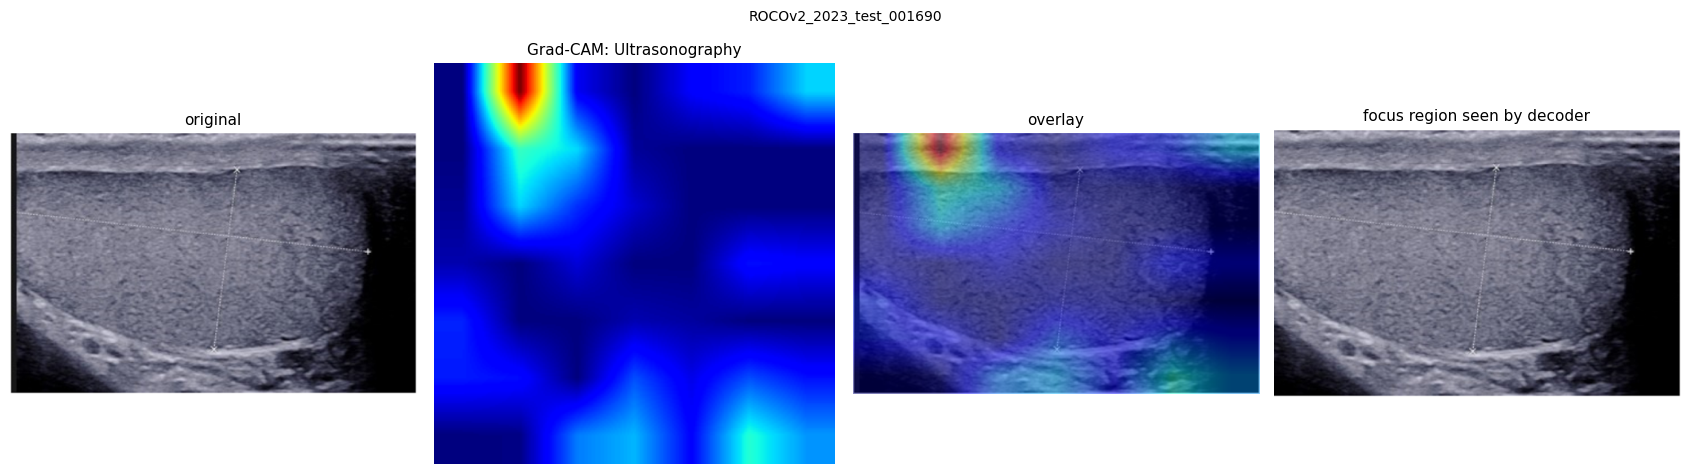

classifier top-4 : Ultrasonography 0.91 | Angiogram 0.54 | Postero-Anterior 0.40 | Magnetic Resonance Imaging 0.13
gold concepts    : Ultrasonography
decoder prompt   : "an ultrasound scan showing"

--- generated explanation ---
The classifier reads this as an ultrasound scan (confidence 0.91), also predicting postero-anterior projection (0.40). Grad-CAM for 'Ultrasonography' concentrates on the centre of the image, covering a tightly localised area (2% of the frame). Blanking it drops the score from 0.91 to 0.41, while a random region of the same size only drops it to 0.63 - the highlighted area really is the evidence the model used. Describing the whole image, the decoder says: "the location of the left side of the abdomen". Describing only the highlighted region, it says: "the location of the cervical bone". Both descriptions mention location, so the region the model relied on carries the same visual content that dominates the image as a whole.

--- for comparison ---
unconditioned 

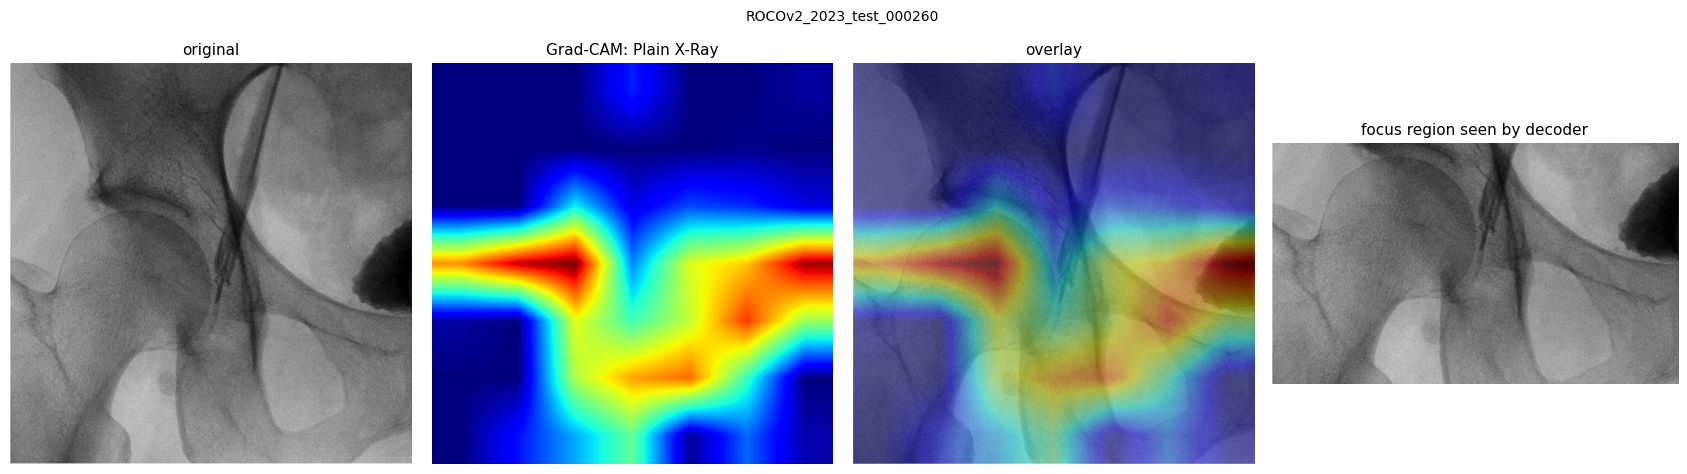

classifier top-4 : Plain X-Ray 1.00 | Anterior-Posterior 0.83 | Lower Extremity 0.24 | Magnetic Resonance Imaging 0.23
gold concepts    : Angiogram
decoder prompt   : "a plain X-ray showing"

--- generated explanation ---
The classifier reads this as a plain X-ray (confidence 1.00), also predicting anterior-posterior projection (0.83). Grad-CAM for 'Plain X-Ray' concentrates on the centre of the image, covering a moderately sized area (25% of the frame). Blanking that region barely moves the score (1.00 -> 1.00), so the highlighted area is not load-bearing - treat this explanation as weak. Describing the whole image, the decoder says: "a plain x - ray showing the fracture in the right side of the left arm". Describing only the highlighted region, it says: "a plain x - ray showing the fracture in the left side of the right arm". Both descriptions mention fracture, left, plain, so the region the model relied on carries the same visual content that dominates the image as a whole.

--- for

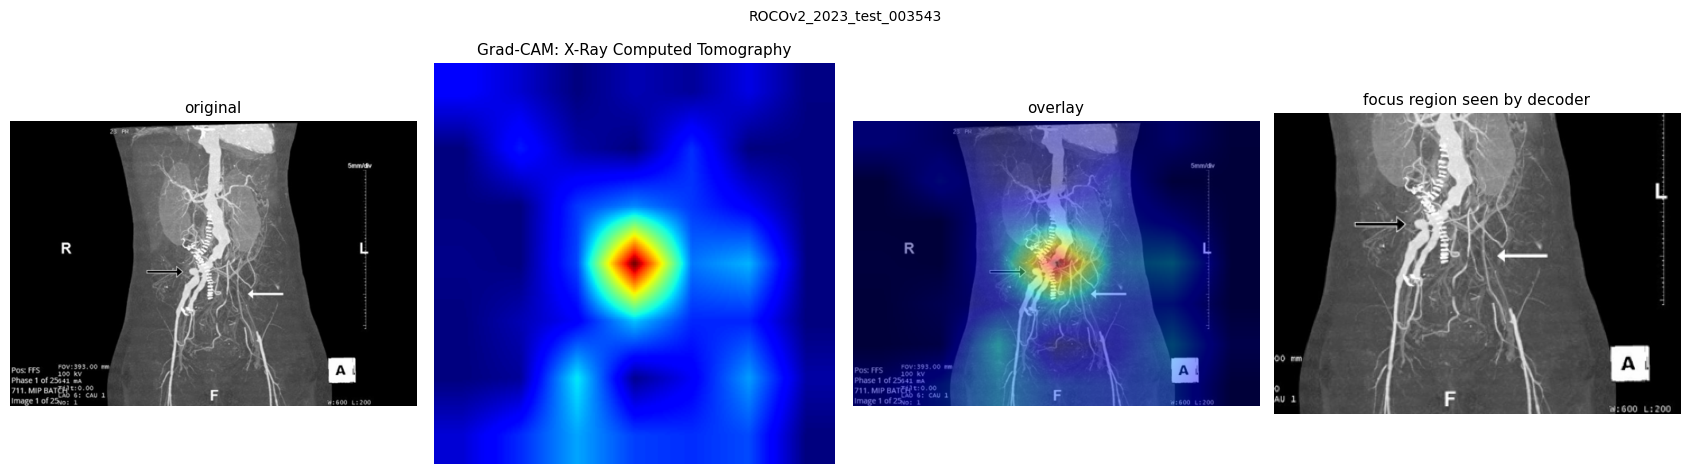

classifier top-4 : X-Ray Computed Tomography 0.99 | Lower Extremity 0.28 | Anterior-Posterior 0.14 | Bone Structure Of Cranium 0.07
gold concepts    : X-Ray Computed Tomography
decoder prompt   : "a CT scan showing"

--- generated explanation ---
The classifier reads this as a CT scan (confidence 0.99). Grad-CAM for 'X-Ray Computed Tomography' concentrates on the centre of the image, covering a tightly localised area (2% of the frame). Blanking it drops the score to 0.95, but blanking a random region of the same size already drops it to 0.63, so the highlight is only marginally more informative than any other part of the frame. Describing the whole image, the decoder says: "the location of the spinal". Describing only the highlighted region, it says: "the left side of the abdomen and the right side of the abdomen". The two descriptions share no vocabulary, which means the model's decision rests on a local detail rather than the overall appearance of the image.

--- for comparison ---
u

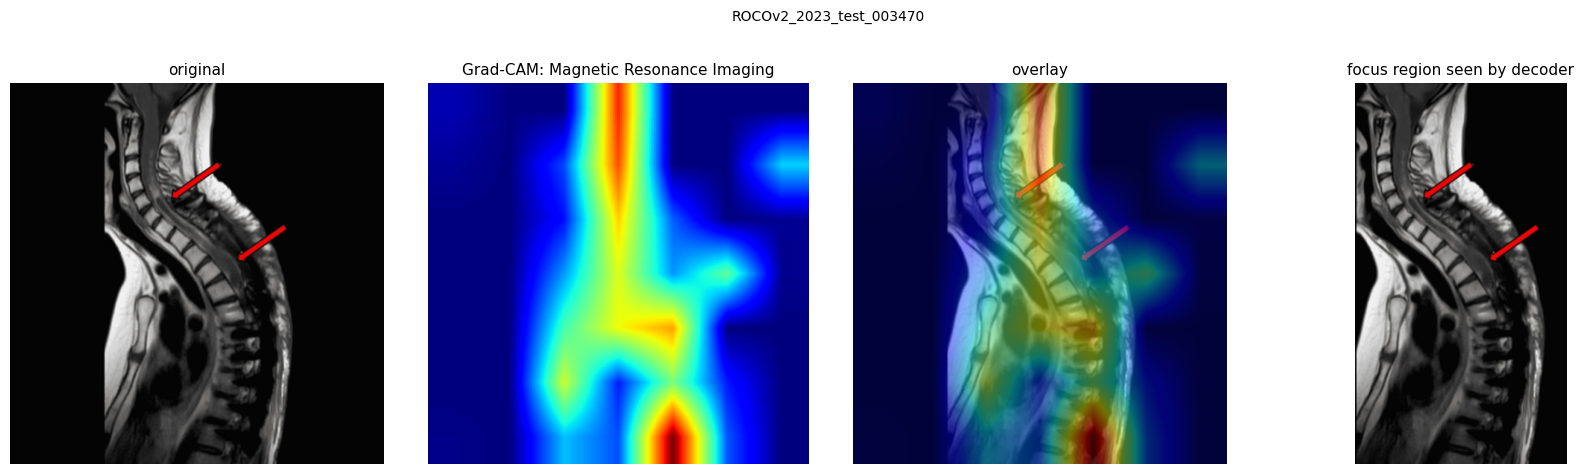

classifier top-4 : Magnetic Resonance Imaging 1.00 | Bone Structure Of Cranium 0.15 | Sagittal 0.10 | Plain X-Ray 0.08
gold concepts    : Magnetic Resonance Imaging
decoder prompt   : "an MRI scan showing"

--- generated explanation ---
The classifier reads this as an MRI scan (confidence 1.00). Grad-CAM for 'Magnetic Resonance Imaging' concentrates on the centre of the image, covering a moderately sized area (14% of the frame). Blanking that region barely moves the score (1.00 -> 0.99), so the highlighted area is not load-bearing - treat this explanation as weak. Describing the whole image, the decoder says: "the location of the cervical bone". Describing only the highlighted region, it says: "the left side of the chest and the right side of the chest". The two descriptions share no vocabulary, which means the model's decision rests on a local detail rather than the overall appearance of the image.

--- for comparison ---
unconditioned caption : an x - ray image of a patient ' s shoul

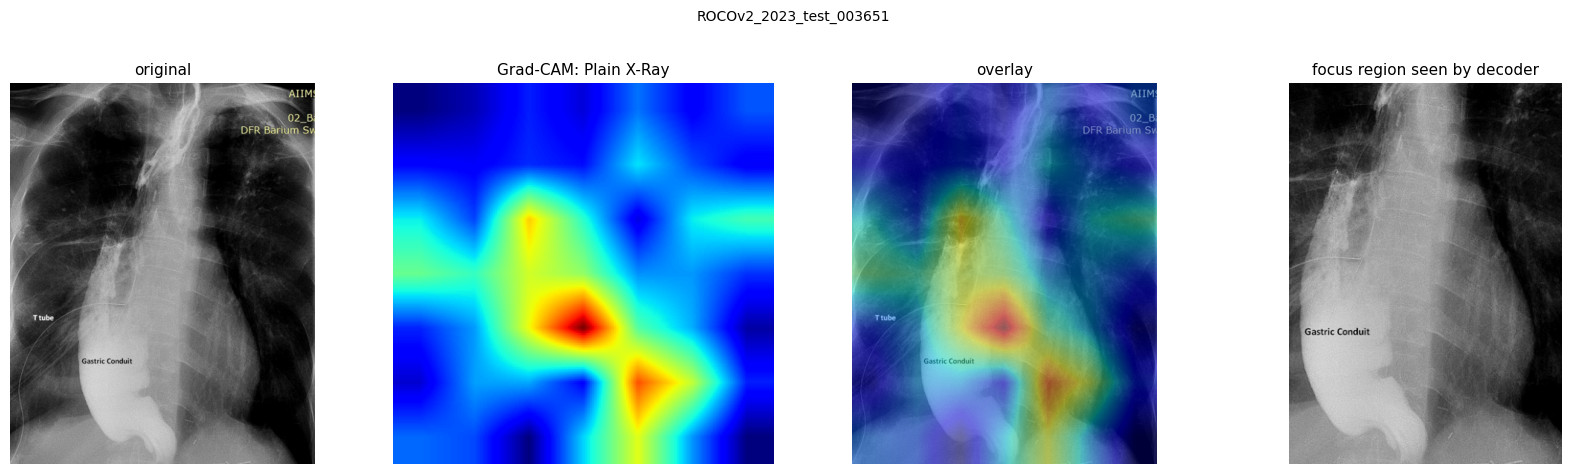

classifier top-4 : Plain X-Ray 1.00 | Chest 0.99 | Postero-Anterior 0.44 | Bone Structure Of Cranium 0.40
gold concepts    : Plain X-Ray, Chest, Postero-Anterior
decoder prompt   : "a plain X-ray of the chest showing"

--- generated explanation ---
The classifier reads this as a plain X-ray (confidence 1.00), also predicting chest (0.99) and postero-anterior projection (0.44). Grad-CAM for 'Plain X-Ray' concentrates on the centre of the image, covering a moderately sized area (15% of the frame). Blanking that region barely moves the score (1.00 -> 1.00), so the highlighted area is not load-bearing - treat this explanation as weak. Describing the whole image, the decoder says: "a plain x - ray of the chest showing a large lump in the right side of the chest, and a large lump in the left side". Describing only the highlighted region, it says: "a plain x - ray of the chest showing the gyric conduct". Both descriptions mention chest, plain, showing, so the region the model relied on carrie

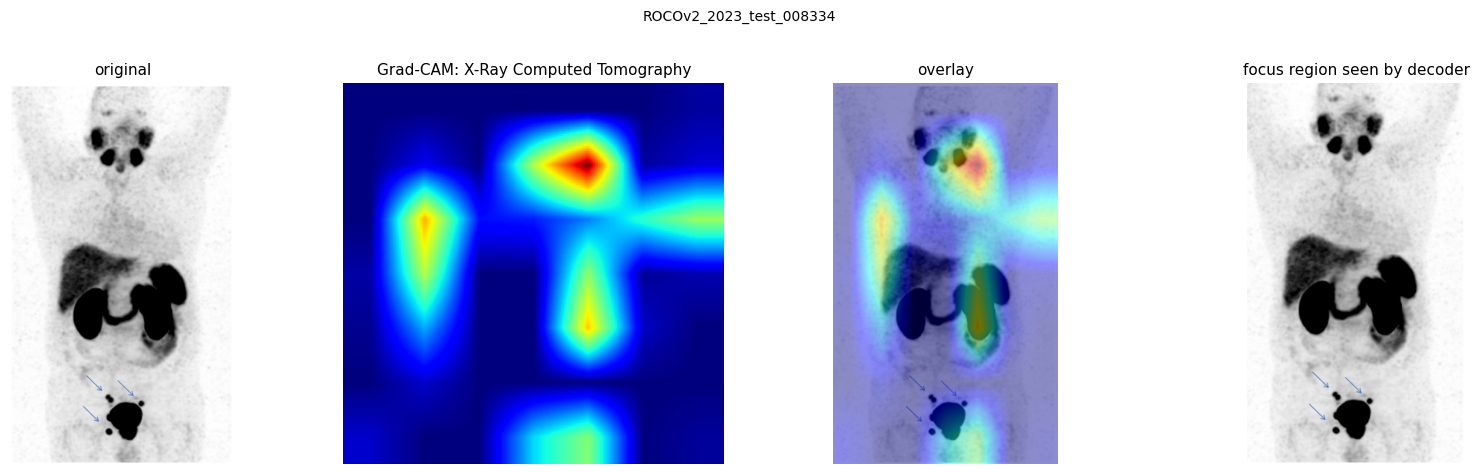

classifier top-4 : X-Ray Computed Tomography 0.42 | Postero-Anterior 0.23 | Angiogram 0.11 | Lower Extremity 0.05
gold concepts    : Positron-Emission Tomography
decoder prompt   : "a CT scan showing"

--- generated explanation ---
The classifier reads this as a CT scan (confidence 0.42). Grad-CAM for 'X-Ray Computed Tomography' concentrates on the centre of the image, covering a tightly localised area (5% of the frame). Blanking it drops the score from 0.42 to 0.09, while a random region of the same size only drops it to 0.30 - the highlighted area really is the evidence the model used. Describing the whole image, the decoder says: "the location of the left and right side of the abdomen". Describing only the highlighted region, it says: "the location of the left and right side of the abdomen". Both descriptions mention abdomen, left, location, so the region the model relied on carries the same visual content that dominates the image as a whole.

--- for comparison ---
unconditioned ca

In [17]:
def show_example(i):
    img = test_data["images"][i]
    res = explain(img)

    fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
    axes[0].imshow(img); axes[0].set_title("original", fontsize=11)
    axes[1].imshow(res["cam"], cmap="jet"); axes[1].set_title(
        f"Grad-CAM: {res['target_name']}", fontsize=11)
    axes[2].imshow(overlay_heatmap(img, res["cam"])); axes[2].set_title("overlay", fontsize=11)
    axes[3].imshow(res["crop"]); axes[3].set_title("focus region seen by decoder", fontsize=11)
    for a in axes:
        a.axis("off")
    plt.suptitle(test_data["ids"][i], fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()

    order = np.argsort(-res["probs"])[:4]
    print("classifier top-4 : " + " | ".join(
        f"{LABEL_NAMES[j]} {res['probs'][j]:.2f}" for j in order))
    print(f"gold concepts    : {', '.join(cui_name(c) for c in test_data['cuis'][i]) or '-'}")
    print(f"decoder prompt   : \"{res['prompt']}\"")
    print()
    print("--- generated explanation ---")
    print(res["explanation"])
    print()
    print("--- for comparison ---")
    print(f"unconditioned caption : {res['cap_plain']}")
    print(f"grounded caption      : {res['grounded']}")
    print(f"gold ROCOv2 caption   : {test_data['captions'][i]}")
    print("=" * 110)
    return res


# Pick examples spanning several modalities so the qualitative set is not all CT.
def pick_examples(n):
    chosen, seen = [], set()
    mod_idx = [i for i in range(K) if LABEL_GROUP[i] == "modality"]
    for i in range(len(test_data["images"])):
        mods = [j for j in mod_idx if Y_test[i, j] > 0]
        key = mods[0] if mods else -1
        if key in seen:
            continue
        seen.add(key)
        chosen.append(i)
        if len(chosen) >= n:
            return chosen
    for i in range(len(test_data["images"])):
        if len(chosen) >= n:
            break
        if i not in chosen:
            chosen.append(i)
    return chosen[:n]


example_idx = pick_examples(CFG["n_qualitative"])
qualitative = [show_example(i) for i in example_idx]

### 8.1 Explaining a different concept on the same image

Grad-CAM is computed per concept, so the same image yields different maps depending on which prediction
you interrogate. This is the most direct demonstration that the explanation is tied to a specific
decision rather than being a generic saliency map.

[Ultrasonography] The classifier reads this as an ultrasound scan (confidence 0.91), also predicting postero-anterior projection (0.40). Grad-CAM for 'Ultrasonography' concentrates on the centre of the image, covering a tightly localised area (2% of the frame). Blanking it drops the score from 0.91 to 0.41, while a random region of the same size only drops it to 0.63 - the highlighted area really is the evidence the model used. Describing the whole image, the decoder says: "the location of the left side of the abdomen". Describing only the highlighted region, it says: "the location of the cervical bone". Both descriptions mention location, so the region the model relied on carries the same visual content that dominates the image as a whole.

[Angiogram] The classifier reads this as an ultrasound scan (confidence 0.91), also predicting postero-anterior projection (0.40). Grad-CAM for 'Angiogram' concentrates on the centre of the image, covering a moderately sized area (12% of the frame)

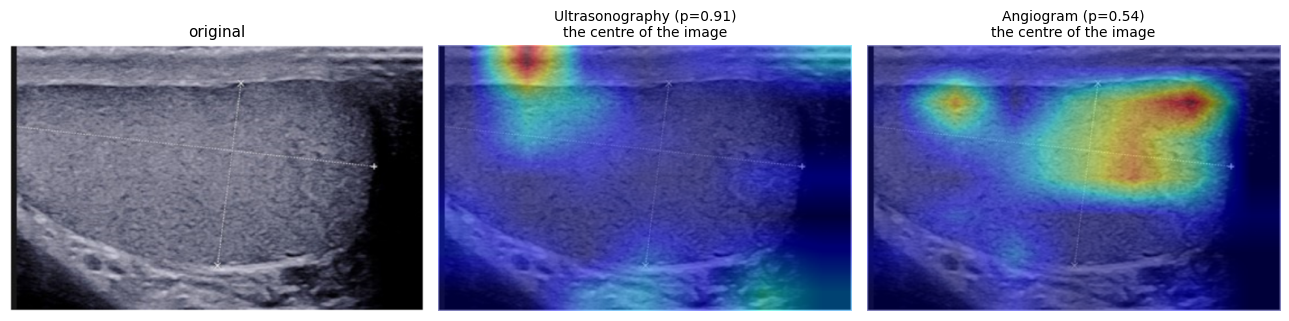

In [18]:
probe_i = example_idx[0]
img = test_data["images"][probe_i]
top2 = np.argsort(-qualitative[0]["probs"])[:2]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].imshow(img); axes[0].set_title("original", fontsize=11); axes[0].axis("off")
for ax, j in zip(axes[1:], top2):
    r = explain(img, target=int(j))
    ax.imshow(overlay_heatmap(img, r["cam"]))
    ax.set_title(f"{LABEL_NAMES[j]} (p={r['probs'][j]:.2f})\n{r['location']}", fontsize=10)
    ax.axis("off")
    print(f"[{LABEL_NAMES[j]}] {r['explanation']}\n")
plt.tight_layout()
plt.show()

## 9. Quantitative evaluation

Three things get measured.

**9.1 Faithfulness of the heatmap** - does the highlighted region carry the decision? Measured as the
mean confidence drop under salient deletion against the same-area random control. This is the metric
that matters most for the research question: it tells you whether the *thing being described in text* is
real.

**9.2 Text quality against gold captions** - BLEU-1..4, ROUGE-L, METEOR, computed with self-contained
implementations (no downloads beyond an optional NLTK resource). Four systems are compared as an
ablation:

| system | description |
|---|---|
| `blip_plain` | BLIP with no conditioning - the "generic caption" baseline |
| `blip_conditioned` | prompted with the classifier's predicted concepts |
| `xai_grounded` | prompt + caption of the Grad-CAM region only |
| `full_explanation` | the complete templated paragraph |

**9.3 Modality-term recall** - a domain check: does the generated text name the imaging modality that
the gold caption names? n-gram metrics are poor proxies for clinical correctness on ROCOv2 (gold
captions describe findings and patient context the image alone cannot support), so this measures the one
thing the pipeline genuinely should get right.

A caveat on interpretation: `full_explanation` is much longer than a gold caption, so BLEU's brevity
penalty and precision denominators punish it heavily. It is included for completeness, but ROUGE recall
and the modality metric are the fairer readings for it.

In [19]:
_WORD = re.compile(r"[a-z0-9]+")

def tok(s):
    return _WORD.findall(s.lower())


def ngrams(t, n):
    return Counter(tuple(t[i:i + n]) for i in range(len(t) - n + 1))


def corpus_bleu(hyps, refs, max_n=4):
    """Corpus BLEU-1..max_n with add-1 smoothing on higher orders."""
    scores = []
    for n in range(1, max_n + 1):
        num = den = 0
        for h, r in zip(hyps, refs):
            th, tr = tok(h), tok(r)
            ch, cr = ngrams(th, n), ngrams(tr, n)
            num += sum(min(c, cr[g]) for g, c in ch.items())
            den += max(sum(ch.values()), 0)
        if den == 0:
            scores.append(0.0)
            continue
        p = (num + (1 if n > 1 else 0)) / (den + (1 if n > 1 else 0))
        scores.append(p)

    hyp_len = sum(len(tok(h)) for h in hyps)
    ref_len = sum(len(tok(r)) for r in refs)
    bp = 1.0 if hyp_len > ref_len else math.exp(1 - ref_len / max(hyp_len, 1))

    out = {}
    for n in range(1, max_n + 1):
        ps = scores[:n]
        gm = math.exp(sum(math.log(max(x, 1e-12)) for x in ps) / n)
        out[f"BLEU-{n}"] = bp * gm
    return out


def lcs_len(a, b):
    prev = [0] * (len(b) + 1)
    for x in a:
        cur = [0]
        for j, y in enumerate(b):
            cur.append(prev[j] + 1 if x == y else max(cur[j], prev[j + 1]))
        prev = cur
    return prev[-1]


def rouge_l(hyps, refs, beta=1.2):
    f, p_, r_ = [], [], []
    for h, r in zip(hyps, refs):
        th, tr = tok(h), tok(r)
        if not th or not tr:
            f.append(0.0); p_.append(0.0); r_.append(0.0); continue
        l = lcs_len(th, tr)
        prec, rec = l / len(th), l / len(tr)
        p_.append(prec); r_.append(rec)
        f.append(0.0 if prec == 0 or rec == 0 else
                 ((1 + beta ** 2) * prec * rec) / (rec + beta ** 2 * prec))
    return {"ROUGE-L": float(np.mean(f)),
            "ROUGE-L-P": float(np.mean(p_)),
            "ROUGE-L-R": float(np.mean(r_))}


# METEOR via NLTK if the wordnet resource is reachable; skipped cleanly otherwise.
METEOR_OK = False
try:
    import nltk
    for res in ["wordnet", "omw-1.4", "punkt"]:
        try:
            nltk.download(res, quiet=True)
        except Exception:
            pass
    from nltk.translate.meteor_score import meteor_score
    _ = meteor_score([["a", "test"]], ["a", "test"])
    METEOR_OK = True
    print("[metrics] METEOR available")
except Exception as e:
    print(f"[metrics] METEOR unavailable ({type(e).__name__}); BLEU/ROUGE only")


def meteor(hyps, refs):
    if not METEOR_OK:
        return {"METEOR": float("nan")}
    return {"METEOR": float(np.mean([meteor_score([tok(r)], tok(h)) for h, r in zip(hyps, refs)]))}


MODALITY_TERMS = {
    "C0040405": ["ct", "computed tomography", "tomography", "cect", "hrct"],
    "C1306645": ["x-ray", "xray", "radiograph", "radiography", "roentgen"],
    "C0024485": ["mri", "magnetic resonance", "mr imaging", "t1", "t2", "flair"],
    "C0041618": ["ultrasound", "ultrasonography", "sonograph", "echo", "doppler"],
    "C0002978": ["angiogra", "angiography", "arteriogra"],
    "C0032743": ["pet", "positron"],
}


def modality_recall(hyps, gold_captions, gold_cuis):
    """Of images whose gold caption names its modality, how often does the hypothesis name it too?"""
    hit = tot = 0
    for h, gc, cs in zip(hyps, gold_captions, gold_cuis):
        mods = [c for c in cs if c in MODALITY_TERMS]
        if not mods:
            continue
        terms = MODALITY_TERMS[mods[0]]
        g = gc.lower()
        if not any(t in g for t in terms):
            continue           # gold caption never names it -> cannot be credited or blamed
        tot += 1
        if any(t in h.lower() for t in terms):
            hit += 1
    return {"modality_recall": hit / max(tot, 1), "modality_n": tot}


def score_all(hyps, refs, gold_cuis):
    out = {}
    out.update(corpus_bleu(hyps, refs))
    out.update(rouge_l(hyps, refs))
    out.update(meteor(hyps, refs))
    out.update(modality_recall(hyps, refs, gold_cuis))
    out["mean_len"] = float(np.mean([len(tok(h)) for h in hyps]))
    return out

[metrics] METEOR available


In [20]:
N = min(CFG["n_eval"], len(test_data["images"]))
print(f"running the full pipeline over {N} held-out images...\n")

systems = defaultdict(list)
faith = {"p_orig": [], "p_del": [], "p_rand": []}
refs, ref_cuis = [], []
t0 = time.time()

for i in range(N):
    res = explain(test_data["images"][i])
    systems["blip_plain"].append(res["cap_plain"])
    systems["blip_conditioned"].append(res["cap_global"])
    systems["xai_grounded"].append(res["grounded"])
    systems["full_explanation"].append(res["explanation"])
    for k in faith:
        faith[k].append(res[k])
    refs.append(test_data["captions"][i])
    ref_cuis.append(test_data["cuis"][i])
    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{N}  ({time.time()-t0:.0f}s)", flush=True)

print(f"done in {time.time()-t0:.0f}s")

running the full pipeline over 150 held-out images...

  25/150  (21s)
  50/150  (43s)
  75/150  (63s)
  100/150  (84s)
  125/150  (105s)
  150/150  (124s)
done in 124s


=== 9.1 heatmap faithfulness (deletion test, top 20% of pixels) ===
mean confidence, unmasked        : 0.956
mean confidence, salient masked  : 0.863   (drop 0.093)
mean confidence, random masked   : 0.663   (drop 0.293)
salient / random drop ratio      : 0.32x
images where salient > random    : 26.7%


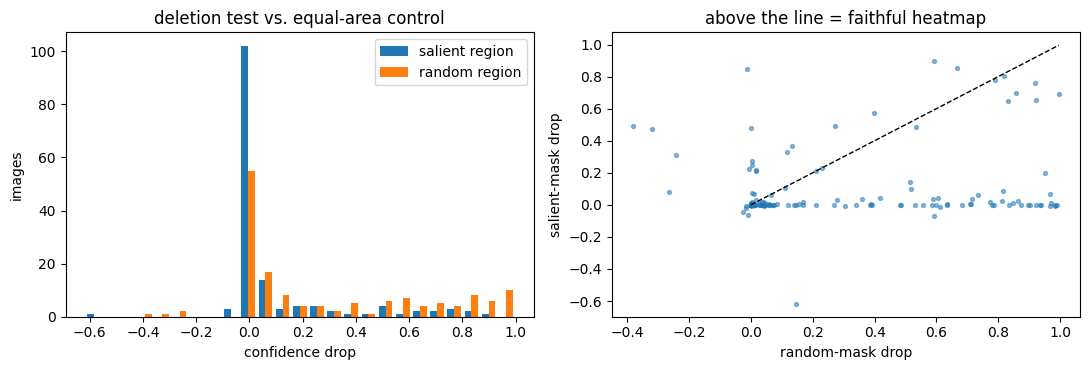

In [21]:
p_orig = np.array(faith["p_orig"])
p_del = np.array(faith["p_del"])
p_rand = np.array(faith["p_rand"])
drop = p_orig - p_del
ctrl = p_orig - p_rand

print("=== 9.1 heatmap faithfulness (deletion test, top "
      f"{int(CFG['cam_delete_frac']*100)}% of pixels) ===")
print(f"mean confidence, unmasked        : {p_orig.mean():.3f}")
print(f"mean confidence, salient masked  : {p_del.mean():.3f}   (drop {drop.mean():.3f})")
print(f"mean confidence, random masked   : {p_rand.mean():.3f}   (drop {ctrl.mean():.3f})")
print(f"salient / random drop ratio      : {drop.mean()/max(ctrl.mean(),1e-6):.2f}x")
print(f"images where salient > random    : {100*np.mean(drop > ctrl):.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist([drop, ctrl], bins=25, label=["salient region", "random region"])
ax[0].set_xlabel("confidence drop"); ax[0].set_ylabel("images")
ax[0].set_title("deletion test vs. equal-area control"); ax[0].legend()
ax[1].scatter(ctrl, drop, s=8, alpha=0.5)
lim = max(drop.max(), ctrl.max(), 0.05)
ax[1].plot([0, lim], [0, lim], "k--", lw=1)
ax[1].set_xlabel("random-mask drop"); ax[1].set_ylabel("salient-mask drop")
ax[1].set_title("above the line = faithful heatmap")
plt.tight_layout(); plt.show()

=== 9.2 / 9.3 text metrics vs. gold ROCOv2 captions (n = 150) ===
(modality_recall computed on the 107 images whose gold caption names its modality)



,system,BLEU-1,BLEU-2,BLEU-3,BLEU-4,ROUGE-L,ROUGE-L-R,METEOR,modality_recall,mean_len
0,blip_plain,0.0852,0.0403,0.0178,0.0079,0.1018,0.0908,0.0716,0.3084,14.3733
1,blip_conditioned,0.0797,0.0403,0.0154,0.0067,0.1341,0.1187,0.0957,0.0654,9.9533
2,xai_grounded,0.1497,0.0725,0.0274,0.0121,0.1557,0.1565,0.1214,0.9533,15.6733
3,full_explanation,0.0462,0.0213,0.0078,0.0030,0.0736,0.2327,0.1105,0.9533,122.8867


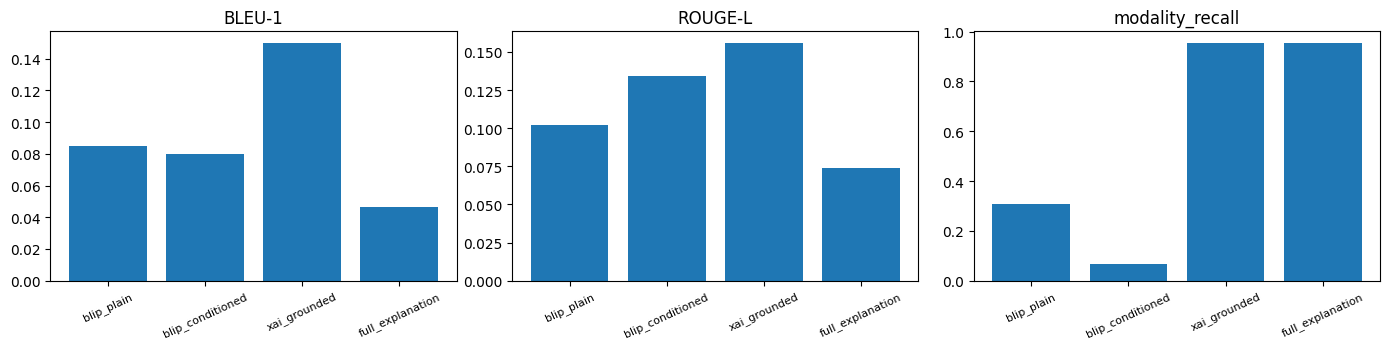

In [22]:
rows = []
for name, hyps in systems.items():
    s = score_all(hyps, refs, ref_cuis)
    s["system"] = name
    rows.append(s)

cols = ["system", "BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4",
        "ROUGE-L", "ROUGE-L-R", "METEOR", "modality_recall", "mean_len"]
results = pd.DataFrame(rows)[cols].round(4)
print(f"=== 9.2 / 9.3 text metrics vs. gold ROCOv2 captions (n = {N}) ===")
print(f"(modality_recall computed on the {rows[0]['modality_n']} images whose gold caption "
      f"names its modality)\n")
display(results)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for a, metric in zip(ax, ["BLEU-1", "ROUGE-L", "modality_recall"]):
    a.bar(results["system"], results[metric])
    a.set_title(metric)
    a.tick_params(axis="x", rotation=25, labelsize=8)
plt.tight_layout(); plt.show()

In [23]:
# Save everything so the run is reproducible / inspectable afterwards.
outdir = "/kaggle/working" if os.path.isdir("/kaggle") else "."
os.makedirs(outdir, exist_ok=True)

results.to_csv(f"{outdir}/xai_text_metrics.csv", index=False)
per_concept.to_csv(f"{outdir}/classifier_per_concept.csv", index=False)
pd.DataFrame({
    "image_id": test_data["ids"][:N],
    "gold_caption": refs,
    "blip_plain": systems["blip_plain"],
    "blip_conditioned": systems["blip_conditioned"],
    "xai_grounded": systems["xai_grounded"],
    "full_explanation": systems["full_explanation"],
    "p_orig": p_orig, "p_salient_masked": p_del, "p_random_masked": p_rand,
}).to_csv(f"{outdir}/xai_generated_explanations.csv", index=False)

torch.save({"weight": head.weight.cpu(), "bias": head.bias.cpu(),
            "label_cuis": LABEL_CUIS, "label_names": LABEL_NAMES},
           f"{outdir}/linear_probe_head.pt")

print("written to", outdir)
for f in sorted(os.listdir(outdir)):
    if f.startswith(("xai_", "classifier_", "linear_probe")):
        print("  ", f)

written to /kaggle/working
   classifier_per_concept.csv
   linear_probe_head.pt
   xai_generated_explanations.csv
   xai_text_metrics.csv


## 10. What this shows, and what it does not

**What worked.** The deletion test is the load-bearing result: if the salient-mask confidence drop
exceeds the equal-area random drop on most images, then the region the explanation talks about really is
the region the classifier used, and the generated sentence "the model is basing this on X" is a true
statement about the model. The modality-recall column shows the effect of grounding directly - prompt
conditioning raises it sharply over the unconditioned baseline, because an unconditioned natural-image
captioner essentially never says "CT".

**Where n-gram metrics mislead.** BLEU and ROUGE against ROCOv2 gold captions are weak evidence here.
Gold captions are PMC figure legends: they mention patient age, prior surgery, follow-up interval and
histology - information no image-only model can recover. A generated sentence can be entirely correct
about the image and still score near zero. Published ImageCLEF systems that *are* fine-tuned on ROCOv2
reach roughly BLEU 0.18 / ROUGE 0.24; a zero-shot general-domain captioner will land well below that,
and that gap is about domain and training, not about the explanation quality.

**Honest limitations.**

1. The backbone is ImageNet-pretrained. Its features were never optimised for radiology, so Grad-CAM
   sometimes highlights high-contrast borders, burned-in annotation text or scanner artefacts rather
   than anatomy. This is visible in the qualitative examples and is a genuine finding about explaining
   off-the-shelf models on medical images, not a bug to hide. Swapping in a medical backbone
   (BiomedCLIP, PubMedCLIP, RadImageNet) while keeping everything else fixed is the obvious next step.
2. BLIP is a general-domain captioner. Its focus-region descriptions are visually literal, not clinical.
   A medically pretrained decoder would change the register of the output text without changing the
   architecture of the pipeline.
3. Grad-CAM at `layer4` has ~7x7 spatial granularity upsampled to 224x224, so "location" claims are
   coarse. For finer maps, use `layer3`, or Grad-CAM++ / HiResCAM.
4. The concept vocabulary is modality, body region and projection - not pathology. The pipeline explains
   *what kind of image this is*, not *what is wrong with the patient*, and the generated text is worded
   to stay inside that claim.
5. The direction concepts (anterior-posterior, postero-anterior, sagittal, transverse) were flagged as
   experimental by the dataset authors (radiologist agreement kappa = 0.56), so predictions on them
   should not be trusted as ground truth.

**Nothing in this notebook is a clinical tool.** It is a research prototype about verbalising XAI output.

### Knobs worth turning
* `CFG["n_train"]` - more probe data, better concept separation, more streaming time.
* `CFG["cam_delete_frac"]` - sweep it to get a proper deletion curve rather than a single point.
* `CFG["top_k_concepts"]` - drop to 6 for modality-only, which makes the heatmaps easier to read.
* `CFG["caption_model"]` - any `*ForConditionalGeneration` captioner with a processor works unchanged.